# 11 · Statistical Arbitrage: Cointegration, Pairs Trading, and the Ornstein-Uhlenbeck Process

*Module 3 — Quantitative Strategies*

Two assets that drift apart in the short run but are tied together in the long run — how to find that relationship rigorously, trade its temporary breakdowns, and know when the relationship itself has quietly stopped being true.

## 1. Motivation

Coca-Cola and Pepsi sell different products, but face the same consumers, the same input costs, and the same economic cycles. Their stock prices tend to drift together over the long run, even though day to day each wobbles on its own. What if we could bet specifically on the moments they drift *apart*, expecting them to come back together — a bet that, done right, does not care which direction the overall market moves?

## 2. Intuition

Pairs trading looks for two assets tied together by real economic fundamentals: not merely *correlated* in their day-to-day returns, but **cointegrated** in their price *levels* — meaning their prices do not wander arbitrarily far apart forever, because some stable long-run relationship keeps pulling them back. When the gap between them stretches unusually wide, bet on convergence: short whichever one looks relatively expensive, go long whichever looks relatively cheap. Because the bet is on the *relationship*, not on either stock's direction, it is designed to be close to market-neutral.

It is worth being precise about a common point of confusion here: **correlation is not cointegration.** Two random walks can have completely uncorrelated day-to-day *returns* and yet their *price levels* could still, by chance, wander apart without any bound — or, in the other direction, two series can be highly correlated in their short-term wiggles while their levels drift arbitrarily far apart over time (think of two unrelated stocks in a strong bull market — both trend up together, so their day-to-day returns look correlated, but nothing ties their price *levels* to each other in the long run). It is specifically cointegration in *levels* that guarantees the *spread* between two assets is mean-reverting — which is the one property a pairs trade actually needs.

## 3. Theory

### 3.1 Stationarity and cointegration, defined precisely

A series $X_t$ is **stationary** if its mean, variance, and autocovariance structure do not change over time — informally, it fluctuates around a fixed level forever, rather than wandering off. A series is **integrated of order 1**, written $I(1)$, if it is *not* stationary, but its first difference is — a random walk (with or without drift) is the standard example.

Two $I(1)$ series $X_t, Y_t$ are **cointegrated** if some linear combination of them is stationary even though neither series is on its own:

$$
S_t = X_t - \beta\, Y_t \quad \text{is } I(0)\ (\text{stationary}), \qquad \text{for some constant } \beta .
$$

$S_t$ is the **spread**, and $\beta$ is the **hedge ratio** — the exact proportion of $Y$ needed to offset $X$'s movements so that what remains reverts to a fixed level, rather than trending off with the rest of the market.

### 3.2 Testing for it: the Engle-Granger two-step procedure

**Step 1.** Regress $X_t = \alpha + \beta Y_t + S_t$ by OLS. This is the *cointegrating regression*; its residual is our estimate of the spread, $\hat S_t$.

**Step 2.** Test $\hat S_t$ for a unit root using the Augmented Dickey-Fuller (ADF) test: under the null hypothesis of non-stationarity, shocks to $\hat S_t$ are *permanent*; under the alternative (stationarity), they *decay*. If we reject the null, we conclude $X$ and $Y$ are cointegrated with hedge ratio $\hat\beta$.

One subtlety worth flagging explicitly, because it is easy to get wrong: $\hat S_t$ is not raw data — it is the *residual of a regression we already ran*, and this changes the test statistic's distribution under the null. Using plain ADF critical values on a regression residual makes the test reject the null of "no cointegration" **too often** (we confirmed this ourselves with a quick simulation while building this notebook: two genuinely unrelated random walks produced a "significant" result an uncomfortably large fraction of the time using naive ADF critical values). Engle and Granger derived the correct, adjusted critical values for exactly this situation; `statsmodels.tsa.stattools.coint` implements the properly-calibrated version, and is what we use below.

### 3.3 Modeling the spread: the Ornstein-Uhlenbeck process

Once we believe $S_t$ is stationary, a natural continuous-time model for its mean-reverting behavior is the **Ornstein-Uhlenbeck (OU) process**:

$$
dS_t = \kappa(\theta - S_t)\,dt + \sigma\, dW_t ,
$$

where $\theta$ is the long-run mean, $\kappa>0$ is the speed of mean reversion, and $\sigma$ is volatility. Discretizing with a small time step $\Delta t$ (Euler-Maruyama) gives

$$
S_{t+\Delta t} \approx S_t + \kappa(\theta - S_t)\Delta t + \sigma\sqrt{\Delta t}\,\varepsilon_t = \underbrace{(1-\kappa\Delta t)}_{b}S_t + \underbrace{\kappa\theta\Delta t}_{a} + \text{noise} ,
$$

which is exactly an **AR(1) model**, $S_{t+1} = a + b\,S_t + \eta_t$. This means we can estimate the OU parameters with nothing more than a simple linear regression of $S_t$ on its own lag, then back them out: $\kappa = (1-b)/\Delta t$ and $\theta = a/(1-b)$.

**Half-life.** Ignoring the stochastic term, the expected path satisfies the linear ODE $\frac{d}{dt}\mathbb E[S_t] = \kappa(\theta - \mathbb E[S_t])$, with solution $\mathbb E[S_t] = \theta + (S_0-\theta)e^{-\kappa t}$. Setting $e^{-\kappa\, HL}=\tfrac12$ gives the **half-life** of mean reversion:

$$
HL = \frac{\ln 2}{\kappa} .
$$

**Stationary variance.** The explicit solution to the OU SDE is $S_t = \theta + (S_0-\theta)e^{-\kappa t} + \sigma\int_0^t e^{-\kappa(t-s)}dW_s$. By the Itô isometry, $\mathrm{Var}(S_t) = \sigma^2\int_0^t e^{-2\kappa(t-s)}ds = \frac{\sigma^2}{2\kappa}\big(1-e^{-2\kappa t}\big) \to \frac{\sigma^2}{2\kappa}$ as $t\to\infty$. This gives us a principled **z-score** for how far the spread currently is from equilibrium, in units of its own natural fluctuation:

$$
z_t = \frac{S_t - \theta}{\sigma/\sqrt{2\kappa}} .
$$

**The trading rule** we implement below: enter a position when $|z_t|$ exceeds a threshold (e.g. 2), betting on reversion; exit when $|z_t|$ falls back below a smaller threshold (e.g. 0.5); the position always shorts the spread when $z$ is high and longs it when $z$ is low.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(13)

## 4. Implementation

### 4.1 Simulating a genuinely cointegrated pair

We build the pair by construction: a common random-walk trend $C_t$ (representing $\log Y_t$) and a stationary OU spread $S_t$, combined as $\log X_t = \beta\, C_t + S_t$. This *guarantees* $X$ and $Y$ are cointegrated with hedge ratio $\beta$, letting us check every method below against a known ground truth.

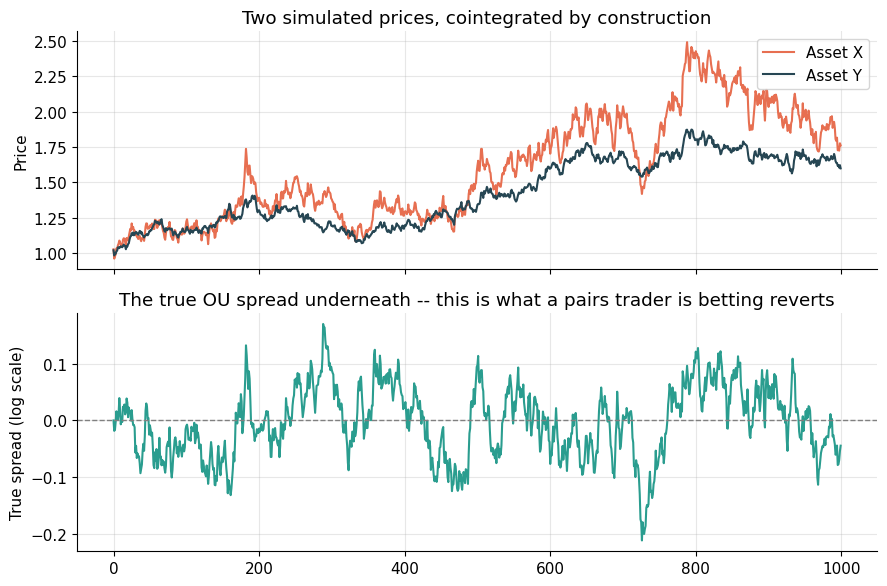

In [2]:
def simulate_cointegrated_pair(T, beta_true, kappa, theta, sigma_ou, mu_trend, sigma_trend, seed):
    local_rng = np.random.default_rng(seed)
    log_Y = np.cumsum(local_rng.normal(mu_trend, sigma_trend, T))    # common stochastic trend
    S = np.zeros(T)
    for t in range(1, T):
        S[t] = S[t-1] + kappa*(theta - S[t-1]) + sigma_ou*local_rng.normal()   # true OU spread
    log_X = beta_true * log_Y + S
    return np.exp(log_X), np.exp(log_Y), S

TRUE_BETA, TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA_OU = 1.30, 0.05, 0.0, 0.02
X, Y, S_true = simulate_cointegrated_pair(T=1000, beta_true=TRUE_BETA, kappa=TRUE_KAPPA, theta=TRUE_THETA,
                                            sigma_ou=TRUE_SIGMA_OU, mu_trend=0.0003, sigma_trend=0.012, seed=13)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(X, label='Asset X', color='#e76f51')
axes[0].plot(Y, label='Asset Y', color='#264653')
axes[0].set_ylabel('Price')
axes[0].set_title('Two simulated prices, cointegrated by construction')
axes[0].legend()
axes[1].plot(S_true, color='#2a9d8f')
axes[1].axhline(TRUE_THETA, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('True spread (log scale)')
axes[1].set_title('The true OU spread underneath -- this is what a pairs trader is betting reverts')
plt.tight_layout()
plt.show()

### 4.2 The Engle-Granger test, and a negative control

We test the true pair, and then -- crucially, as good scientific practice -- also test two genuinely *unrelated* simulated random walks, to confirm the test does not simply "find" cointegration everywhere.

In [3]:
log_X, log_Y = np.log(X), np.log(Y)
eg_reg = sm.OLS(log_X, sm.add_constant(log_Y)).fit()
beta_hat = eg_reg.params[1]
spread_hat = (log_X - beta_hat * log_Y)

t_stat, pval, crit_values = coint(log_X, log_Y)
print(f"Estimated hedge ratio beta_hat: {beta_hat:.4f}  (true: {TRUE_BETA})")
print(f"Engle-Granger cointegration test: statistic={t_stat:.3f}, p-value={pval:.5f}")
print(f"Critical values (1%/5%/10%): {np.round(crit_values, 3)}")

# Negative control: two INDEPENDENT random walks with no true relationship
rng_neg = np.random.default_rng(1)
X_indep = np.exp(np.cumsum(rng_neg.normal(0.0003, 0.012, 1000)))
Y_indep = np.exp(np.cumsum(rng_neg.normal(0.0003, 0.012, 1000)))
t_neg, p_neg, _ = coint(np.log(X_indep), np.log(Y_indep))
print(f"\nNegative control (unrelated random walks): p-value={p_neg:.4f}  "
      f"-- correctly {'fails to reject' if p_neg > 0.05 else 'incorrectly rejects'} the no-cointegration null.")

Estimated hedge ratio beta_hat: 1.3287  (true: 1.3)
Engle-Granger cointegration test: statistic=-5.092, p-value=0.00011
Critical values (1%/5%/10%): [-3.907 -3.342 -3.049]

Negative control (unrelated random walks): p-value=0.4446  -- correctly fails to reject the no-cointegration null.


### 4.3 Fitting the OU process via the AR(1) regression trick

In [4]:
def fit_ou_via_ar1(spread):
    """Section 3.3: kappa, theta, sigma from a simple AR(1) regression of the spread on its own lag."""
    s_lag, s_now = spread[:-1], spread[1:]
    ar_fit = sm.OLS(s_now, sm.add_constant(s_lag)).fit()
    a, b = ar_fit.params
    kappa_hat = 1 - b
    theta_hat = a / (1 - b)
    sigma_hat = ar_fit.resid.std()
    return kappa_hat, theta_hat, sigma_hat

kappa_hat, theta_hat, sigma_hat = fit_ou_via_ar1(spread_hat)
halflife_hat = np.log(2) / kappa_hat

print(f"{'Parameter':<12}{'True':>10}{'Estimated':>12}")
print(f"{'kappa':<12}{TRUE_KAPPA:>10.4f}{kappa_hat:>12.4f}")
print(f"{'theta':<12}{TRUE_THETA:>10.4f}{theta_hat:>12.4f}")
print(f"{'sigma':<12}{TRUE_SIGMA_OU:>10.4f}{sigma_hat:>12.4f}")
print(f"{'half-life':<12}{np.log(2)/TRUE_KAPPA:>10.2f}{halflife_hat:>12.2f}  (days)")

Parameter         True   Estimated
kappa           0.0500      0.0509
theta           0.0000     -0.0144
sigma           0.0200      0.0196
half-life        13.86       13.62  (days)


## 5. Worked example

### 5.1 The z-score trading rule

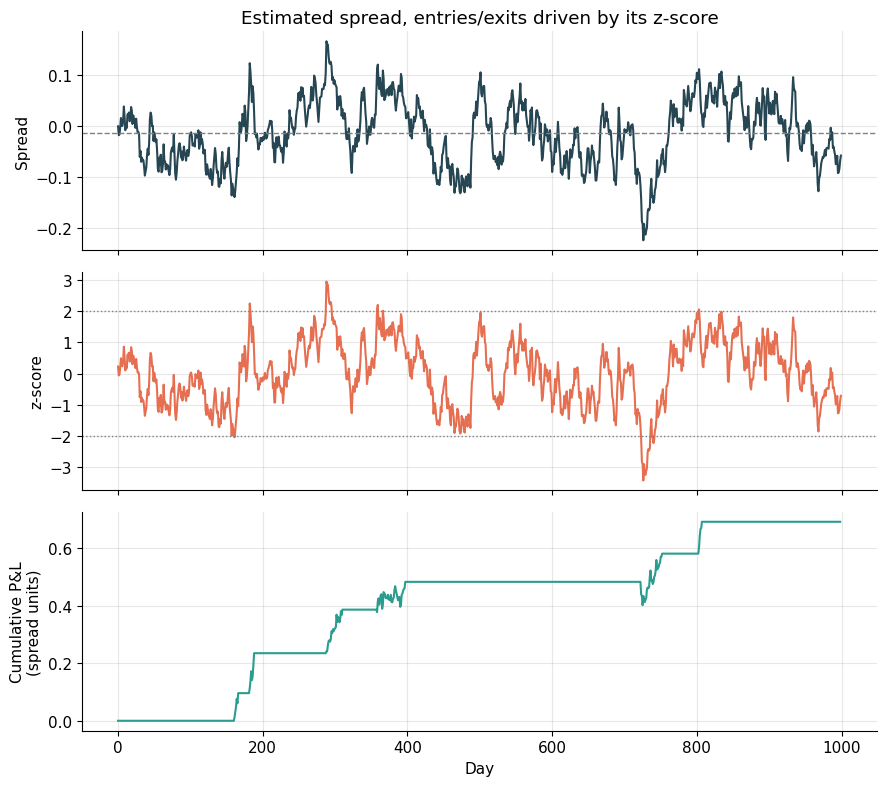

Approximate number of round-trip trades: 6
Total P&L (in spread units): 0.6921


In [5]:
def backtest_pairs(spread, theta, kappa, sigma, entry_z=2.0, exit_z=0.5):
    """Section 3.3's trading rule. Position at time t is decided using info available AT t;
    P&L from t to t+1 uses that position applied to the spread's actual move over that period."""
    stationary_sigma = sigma / np.sqrt(2 * kappa)
    z = (spread - theta) / stationary_sigma

    n = len(spread)
    position = np.zeros(n)
    pos = 0
    for t in range(n):
        if pos == 0:
            if z[t] > entry_z:
                pos = -1     # spread unusually high -> bet it falls
            elif z[t] < -entry_z:
                pos = 1      # spread unusually low -> bet it rises
        elif abs(z[t]) < exit_z:
            pos = 0
        position[t] = pos

    spread_change = np.diff(spread)
    pnl = position[:-1] * spread_change
    return z, position, pnl

z, position, pnl = backtest_pairs(spread_hat, theta_hat, kappa_hat, sigma_hat)
cum_pnl = np.cumsum(pnl)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(spread_hat, color='#264653')
axes[0].axhline(theta_hat, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylabel('Spread')
axes[0].set_title('Estimated spread, entries/exits driven by its z-score')

axes[1].plot(z, color='#e76f51')
axes[1].axhline(2, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(-2, color='gray', linestyle=':', linewidth=1)
axes[1].set_ylabel('z-score')

axes[2].plot(cum_pnl, color='#2a9d8f')
axes[2].set_ylabel('Cumulative P&L\n(spread units)')
axes[2].set_xlabel('Day')

plt.tight_layout()
plt.show()

n_trades = np.sum(np.diff(position) != 0) // 2
print(f"Approximate number of round-trip trades: {n_trades}")
print(f"Total P&L (in spread units): {cum_pnl[-1]:.4f}")

### 5.2 What happens when the relationship breaks?

Cointegration is an empirical, historical finding, not a law of physics — the relationship can and does break down (a merger, a fundamental change in one company's business, a shift in the industry). We simulate exactly that: halfway through, we turn off mean reversion entirely and let the "spread" trend on its own.

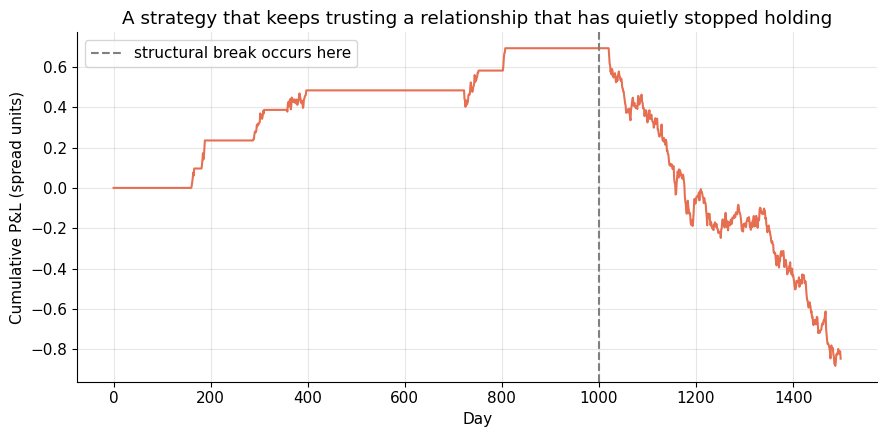

In [6]:
T_break = 1000
S_break = np.concatenate([S_true, np.zeros(500)])
for t in range(1000, 1500):
    S_break[t] = S_break[t-1] + 0.003 + 0.02*rng.normal()   # kappa=0 from here on: no more mean reversion

log_Y_ext = np.concatenate([log_Y, log_Y[-1] + np.cumsum(rng.normal(0.0003, 0.012, 500))])
log_X_ext = TRUE_BETA * log_Y_ext + S_break
spread_break = (log_X_ext - beta_hat * log_Y_ext)  # trader still uses the ORIGINAL beta_hat, unaware of the break

z_break, pos_break, pnl_break = backtest_pairs(spread_break, theta_hat, kappa_hat, sigma_hat)

fig, ax = plt.subplots()
ax.plot(np.cumsum(pnl_break), color='#e76f51')
ax.axvline(T_break, color='gray', linestyle='--', label='structural break occurs here')
ax.set_ylabel('Cumulative P&L (spread units)')
ax.set_xlabel('Day')
ax.set_title('A strategy that keeps trusting a relationship that has quietly stopped holding')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

Before the break, the z-score rule earns a steady, if modest, P&L by repeatedly betting on (and being rewarded for) reversion to a genuinely stable mean — report your own run's total P&L and trade count above. After the break, the spread stops reverting and instead trends, but the strategy keeps applying the *same* rule, entering positions that assume reversion to a mean that no longer describes the data. Watch what happens to cumulative P&L after the dashed line in your own run: this is precisely the risk every real pairs trader lives with, and precisely why the risk controls in Exercise 3 (a maximum holding period, a hard stop) are not optional extras.

## 6. Limitations and pitfalls

- **Cointegration relationships break down in reality, not just in our deliberately constructed example** — mergers, regulatory changes, a company entering or exiting an industry, or simply a slow fundamental drift can end a once-genuine relationship with no advance warning.
- **The Engle-Granger test treats the two assets asymmetrically** — regressing $X$ on $Y$ versus $Y$ on $X$ can give somewhat different results in finite samples, since OLS is not symmetric between the two variables. Notebook 17's Johansen test fixes this by treating all variables in a multivariate system symmetrically, and extends naturally to baskets of more than two assets.
- **Entry and exit z-score thresholds are hyperparameters** chosen by the researcher, not derived from theory — searching over many threshold combinations and reporting only the best one is a direct form of overfitting.
- **A hedge ratio and half-life estimated in-sample may not stay constant out-of-sample.** If $\kappa$ itself drifts over time, a static OU fit becomes stale — Notebook 15's Kalman filter is built specifically to track a hedge ratio that evolves.
- **Screening many candidate pairs for cointegration is itself a multiple-testing problem.** Test a few hundred pairs at a 5% significance threshold, and you should *expect* a meaningful number of "significant" results purely by chance, exactly the phenomenon Notebook 30's Harvey-Liu-Zhu correction addresses directly.

## 7. Exercises

**1. Confirm the negative control yourself (warm-up).**
Generate a fresh pair of independent random walks with a different seed than the one used in Section 4.2, run `coint()` on them, and report the p-value. Repeat this ten times with ten different seeds and record how many come out below 0.05. Does the fraction roughly match what a well-calibrated 5%-significance test should produce by chance alone?

**2. What makes a spread good to trade?**
Rerun the Section 4.1 simulation with `kappa` set to a much smaller value (e.g. 0.01, very slow reversion) and separately to a much larger value (e.g. 0.20, very fast reversion), holding everything else fixed. For each, refit the OU process, compute the half-life, and rerun the Section 5.1 backtest. How does trading frequency and realized Sharpe ratio change with the speed of mean reversion? Is there such a thing as reversion that is "too fast" to trade profitably once you think about realistic execution frictions?

**3. Add costs and a stop.**
Add a per-trade transaction cost (in basis points of notional, applied whenever `position` changes) and a maximum holding period (force-close any open position that has not reverted within, say, 60 days) to `backtest_pairs`. Then re-optimize the entry and exit z-score thresholds under these more realistic frictions using a small grid search. How much does the optimal threshold shift once costs and a hard time-stop are accounted for, compared to the frictionless version in Section 5.1?